In [1]:
import pandas as pd
import numpy as np

In [2]:
from openai import OpenAI

In [9]:
client = OpenAI(
    base_url="http://192.168.15.182:1234/v1",
    api_key="sk-no-key-required"
)

In [ ]:
response = client.chat.completions.create(
    model="qwen/qwen3.5-35b-a3b",
    messages=[
        {"role": "user", "content": "Привет! Напиши одно короткое приветствие."}
    ]
)

In [21]:
print(response.choices[0].message.content)



Привет! 👋 Я — **Qwen3.5**, последняя версия большой языковой модели от Tongyi Lab. 

Я оптимизирован для эффективной работы: моя архитектура позволяет быстро обрабатывать сложные запросы, будь то анализ документов, генерация кода или креативные задачи. Хотя я не раскрываю точные технические детали (например, количество параметров), я спроектирован так, чтобы балансировать между мощью и скоростью — это значит, что вы получаете качественные результаты без лишних задержек. 

Чем могу помочь? 😊


In [7]:
df_RAG_questions = pd.read_csv(
    "AI_chat_bot_answers_all.csv",
    encoding="utf-8-sig",
    sep=";"
)

In [8]:
# Сохраняем в Excel
df_RAG_questions.to_excel("AI_chat_bot_answers_all_20260623.xlsx", 
                    index=False,
                    engine='openpyxl')

In [7]:
df_RAG_questions = pd.read_csv(
    "AI_chat_bot_answers_ragas_test.csv",
    encoding="utf-8-sig",
    sep=";"
)

In [9]:
df_RAG_questions.head(1)

,id,domain,source_type,source_id,source_url,question_type,difficulty,question,context,expected_answer,...,manual_final_score,manual_comment,model,temperature,latency_sec,created_at,prompt_tokens,completion_tokens,total_tokens,error
0,rag_question_001,Детский мир,sapiense,NaN,NaN,NaN,NaN,Как загрузить табеля вручную?,NaN,"Для ручной выгрузки табелей самозанятых, нужно...",...,NaN,NaN,NaN,NaN,24.793,2026-06-22T11:28:52,NaN,NaN,NaN,NaN


In [10]:
df_RAG_questions.to_excel("AI_chat_bot_answers_ragas_test.xlsx", 
                    index=False,
                    engine='openpyxl')

### Оценка ragas

In [9]:
df_ragas = pd.read_csv(
    "Ragas_answers_all_AI_chat_bot.csv",
    encoding="utf-8-sig",
    sep=";"
)

In [10]:
df_ragas.to_excel("ragas_metrics.xlsx", 
                    index=False,
                    engine='openpyxl')

In [11]:
df_ragas_summary = pd.read_csv(
    "summary_data\\ragas_final_table.csv",
    encoding="utf-8-sig",
    sep=";"
)

In [13]:
df_ragas_summary.head(2)

,id,domain,source_type,question,expected_answer,model_answer,ragas_factual_correctness,ragas_semantic_similarity,ragas_final_score,manual_final_score,latency_sec
0,rag_question_001,Детский мир,sapiense,Как загрузить табеля вручную?,"Для ручной выгрузки табелей самозанятых, нужно...",## Ручная загрузка табелей\n\nСогласно инструк...,"0,43","0,4858",2,2,"24,793"
1,rag_question_002,Детский мир,sapiense,Как обновить ранее загруженные данные по табел...,При загрузке табелей происходит полная перезап...,## Обновление ранее загруженных данных по табе...,"0,59","0,882",2,2,"24,509"


In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

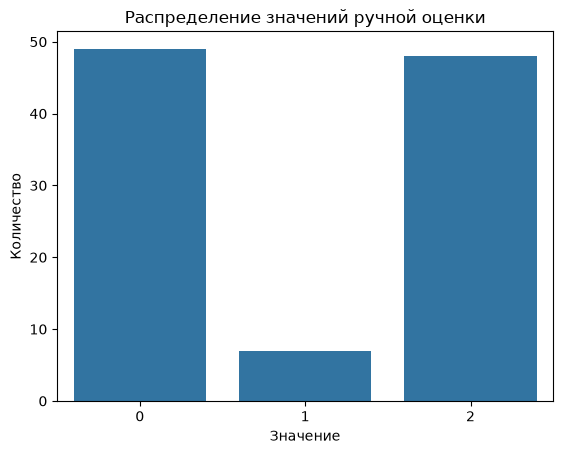

In [22]:
sns.countplot(
    data=df_ragas_summary,
    x="manual_final_score",
    order=[0, 1, 2]
)

plt.xlabel("Значение")
plt.ylabel("Количество")
plt.title("Распределение значений ручной оценки")
plt.show()

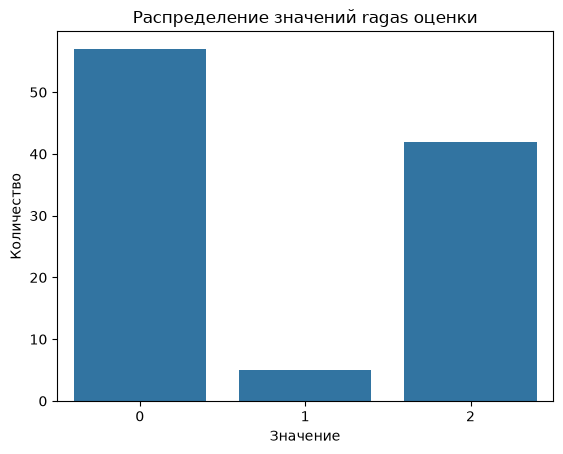

In [24]:
sns.countplot(
    data=df_ragas_summary,
    x="ragas_final_score",
    order=[0, 1, 2]
)

plt.xlabel("Значение")
plt.ylabel("Количество")
plt.title("Распределение значений ragas оценки")
plt.show()

In [17]:
df_ragas_summary.manual_final_score.mean()

np.float64(0.9903846153846154)

In [18]:
df_ragas_summary.ragas_final_score.mean()

np.float64(0.8557692307692307)

In [21]:
df_ragas_summary.dtypes

id                             str
domain                         str
source_type                    str
question                       str
expected_answer                str
model_answer                   str
ragas_factual_correctness      str
ragas_semantic_similarity      str
ragas_final_score            int64
manual_final_score           int64
latency_sec                    str
dtype: object